<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/RepresentacionTextoEmbeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicios de representación de texto (embeddings)**

* Asignatura: Procesamiento del Lenguaje Natural
* Profesor: Dr. Rogelio Florencia Juárez
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 10 de marzo de 2026




**Visualización semántica de palabras utilizando embeddings y t-SNE**<br>
Explorar la representación semántica de palabras e identifica los diferentes dominios temáticos contenidos en el conjunto de datos proporcionado mediante la visualización 2D de embeddings de palabras. Realiza y define las actividades de preprocesamiento del texto (si lo crees necesario) para que fácilmente puedas identificar en la visualización lo siguiente:
1. ¿Cuántos dominios o grupos de datos puedes identificar visualmente en la gráfica?
2.	¿Cuáles son esos dominios?

Instrucciones adicionales:
* Genera la gráfica 2D de los embeddings de palabras utilizando t-SNE.
* Visualiza en la gráfica las palabras de cada uno de los puntos.
*	De manera manual, encierra aproximadamente con óvalos los grupos o dominios que hayas identificado.
*	Incluye la gráfica final y tus observaciones en el documento de entrega.


In [ ]:
# Instalar librerías
!pip install gensim matplotlib scikit-learn nltk

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import gensim.downloader as api
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Descargar recursos de NLTK para limpiar el texto
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# 2. Cargar el texto desde el archivo csv
texto = pd.read_csv("/content/drive/MyDrive/ClassFiles/texto_embeddings.csv")
texto.head()

,frase
0,La ciberseguridad protege la información digit...
1,La inteligencia artificial transforma múltiple...
2,"El baloncesto combina velocidad, técnica y tra..."
3,El hardware y el software son complementarios ...
4,La democracia permite la participación ciudada...


In [ ]:
# 3. Preprocesamiento: Limpieza y extracción de palabras clave
stop_words = set(stopwords.words('spanish'))
palabras_limpias = set()

for linea in texto['frase']:
    # Convertir a minúsculas y separar en palabras
    tokens = word_tokenize(linea.lower())
    for token in tokens:
        # Conservar solo palabras (sin signos de puntuación) que no sean stopwords
        if token.isalpha() and token not in stop_words:
            palabras_limpias.add(token)

palabras_limpias = list(palabras_limpias)
print(f"Palabras a visualizar ({len(palabras_limpias)}):", palabras_limpias)

Palabras a visualizar (72): ['combina', 'algoritmos', 'base', 'necesidades', 'decisiones', 'fortalece', 'olimpismo', 'nube', 'programación', 'deporte', 'deportes', 'esenciales', 'entrenamiento', 'políticas', 'unión', 'hardware', 'procesar', 'constante', 'pueblos', 'mejorar', 'representan', 'software', 'populares', 'informática', 'democrática', 'vida', 'requieren', 'disciplina', 'elecciones', 'buscan', 'técnica', 'atender', 'computación', 'sociales', 'participación', 'derecho', 'mundo', 'transforma', 'datos', 'públicas', 'velocidad', 'información', 'gran', 'diferentes', 'democracia', 'artificial', 'almacenar', 'digital', 'permite', 'busca', 'baloncesto', 'políticos', 'protege', 'atletas', 'ciberseguridad', 'inteligencia', 'complementarios', 'fútbol', 'equipo', 'ideologías', 'ciudadana', 'cuerpo', 'escala', 'libres', 'través', 'trabajo', 'público', 'múltiples', 'natación', 'industrias', 'debate', 'partidos']


In [ ]:
# 4. Cargar el modelo preentrenado (¡Esto garantiza excelentes agrupaciones!)
print("\nCargando modelo FastText... (Paciencia, toma un momento)")
model = api.load("fasttext-wiki-news-subwords-300")
print("¡Modelo cargado!")

# Filtrar palabras que existan en el modelo
palabras_filtradas = [p for p in palabras_limpias if p in model.key_to_index]


Cargando modelo FastText... (Paciencia, toma un momento)
[==================================================] 100.0% 958.5/958.4MB downloaded
¡Modelo cargado!


In [ ]:
# 5. Obtener los embeddings de las palabras
X = np.array([model[p] for p in palabras_filtradas])
print(X.shape)
print(X[0])

(60, 300)
[ 5.2648e-03  1.4456e-03 -2.0085e-02  1.9691e-02  2.2381e-02 -2.7786e-03
 -2.0846e-03 -8.0936e-02 -7.4936e-03 -2.4471e-02 -2.1407e-03 -1.8958e-02
 -8.2371e-03 -1.4483e-02 -1.1993e-02  2.4439e-02  9.8619e-02  1.9630e-03
  5.9617e-02  2.3317e-02 -3.8711e-02 -1.8220e-02 -3.6764e-03  3.1584e-02
  2.4220e-02  1.5710e-02  3.5743e-03 -6.8654e-03 -1.1992e-02 -1.1359e-03
  8.4655e-03 -4.9717e-03 -7.6975e-03 -1.6433e-02 -1.2120e-03 -7.7442e-05
  4.6817e-02  2.6425e-02 -5.4684e-03  1.5249e-02  1.1420e-02 -4.0786e-02
 -1.9829e-02 -5.4546e-03  3.8037e-02 -1.3890e-02 -1.7581e-02  1.8212e-04
  7.6377e-02 -3.4141e-02 -3.2058e-02 -1.9381e-02 -4.7295e-04  7.0566e-03
 -1.2436e-02 -5.2320e-03  1.4067e-02  2.3765e-02 -2.1711e-02  2.6431e-02
 -6.6122e-02 -1.0074e-02  6.2669e-02  5.8490e-03  3.1039e-02 -1.1809e-02
 -4.4427e-03  1.9419e-02  1.4392e-03 -1.2193e-02 -6.3660e-03 -2.5993e-03
  5.2316e-02 -1.8810e-02  3.1595e-02 -2.6197e-02 -3.5505e-02 -1.5100e-02
 -1.4761e-02 -1.1767e-02 -5.8761e-02  6.0

In [ ]:
# 6. Reducción de dimensionalidad con t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5, init="pca")
X_2d = tsne.fit_transform(X)
print(X_2d.shape)
print(X_2d)

(60, 2)
[[  9.70964     13.312377  ]
 [ 19.422203    10.660349  ]
 [  2.4109101  -30.200727  ]
 [  5.599216    -7.9981556 ]
 [ 12.643457    22.909193  ]
 [-14.768736     6.6999393 ]
 [ 19.286463   -12.459813  ]
 [ 16.642887   -13.391057  ]
 [-20.208858     0.60000134]
 [-28.830408   -14.287348  ]
 [-22.634298     9.385977  ]
 [ 41.58573     19.713724  ]
 [ 11.707428    17.627092  ]
 [ -0.11032603 -15.246526  ]
 [-28.925583    -7.0793395 ]
 [ 15.078876    10.031214  ]
 [ 39.681988    21.241411  ]
 [-14.54015    -10.044445  ]
 [ -2.0921006    6.0814414 ]
 [ -6.2746606   -3.7968419 ]
 [ -5.82096     25.092815  ]
 [  3.4879425    4.414495  ]
 [  3.399996   -10.233512  ]
 [ -8.857199   -26.255854  ]
 [ -6.023349     3.5788274 ]
 [ 24.269009     5.8281665 ]
 [-24.706423   -19.175303  ]
 [-15.856887    10.190805  ]
 [ 19.75967     -6.6030984 ]
 [  3.199632    23.60594   ]
 [ 12.805276    12.699803  ]
 [ 11.497277   -16.246866  ]
 [-32.719246   -15.882817  ]
 [-17.450909    16.20385   ]
 [-12.

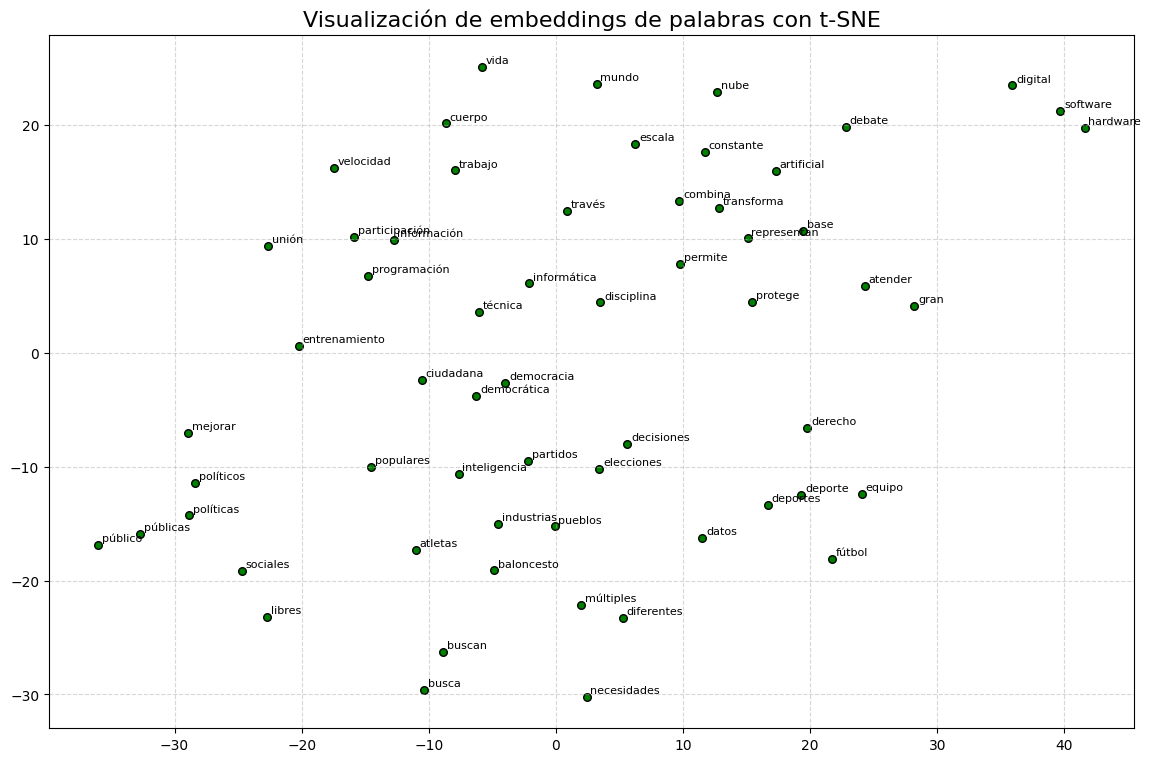

In [ ]:
# 7. Visualización
plt.figure(figsize=(14, 9))
for i, palabra in enumerate(palabras_filtradas):
    x, y = X_2d[i, 0], X_2d[i, 1]
    plt.scatter(x, y, c="green", s=30, edgecolors='k')
    plt.text(x + 0.3, y + 0.3, palabra, fontsize=8)

plt.title("Visualización de embeddings de palabras con t-SNE", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

* **¿Cuántos dominios o grupos de datos puedes identificar visualmente en la gráfica?**
Se observan claramente 8 dominios
* **¿Cuáles son esos dominios?**
  * Deportes 1: atletas, baloncesto, múltiples, diferentes.
  * Deportes 2: futbol, equipo, deporte, deportes, datos.
  * Políticos 1: mejorar, políticos, políticas, públicas, público, sociales, libres, populares.
  * Políticos 2: inteligencia, industrias, partidos, elecciones, decisiones, democracia, democrática, ciudadana.
  * Informática: velocidad, participación, información, programación, técnica, informática, disciplina.
  * Humano: vida, mundo, cuerpo, trabajo, través, escala.
  * Tecnología: digital, software, hardware.
  * Acciones: atender, protege, representan, permite, transforma, combina.

* **Conclusiones**
Es importante realizar una limpieza para eliminar stopwords y signos de puntiación, así como tener todo el texto en minúsculas. El modelo FasText arroja buenos resultados para capturar el significado semántico de las palabras en español y con el algoritmo de t-SNE se reduce el volumen de los vectores a un plano 2D, para que podamos tener buenas observaciones en la gráfica

Código disponible en:

```
https://colab.research.google.com/drive/1DB08EdswcO9Brj6pl5dS1x0Lv2B93FyY?usp=sharing
```

